# Libraries

In [116]:
import pandas as pd
import numpy as np

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from IPython.display import Image, display
import os
import matplotlib.font_manager as fm
import time
import warnings
import statsmodels.api as sm

# Plotting Libs
import matplotlib.pyplot as plt 
from sklearn.tree import plot_tree
from xgboost import plot_importance
import shap

# Scaler Libs
from sklearn.preprocessing import MinMaxScaler

# CV Libs
from sklearn.model_selection import GridSearchCV 
from xgboost import XGBClassifier

# Accuracy Libs
from sklearn.metrics import accuracy_score , classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score

# Resampling Libs
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

# Load Plots

In [117]:
# ROC_AIC Plots
roc1 = f"roc_plots/roc_df1.png"
roc2 = f"roc_plots/roc_df2.png"
roc3 = f"roc_plots/roc_df3.png"
roc4 = f"roc_plots/roc_df4.png"

# SHAP Plots
lgb_shap1 = f"shap_plots/df1_LightGBM_shap_plot.png"
lgb_shap2 = f"shap_plots/df2_LightGBM_shap_plot.png"
lgb_shap3 = f"shap_plots/df3_LightGBM_shap_plot.png"
lgb_shap4 = f"shap_plots/df4_LightGBM_shap_plot.png"

xgb_shap1 = f"shap_plots/df1_XGBoost_shap_plot.png"
xgb_shap2 = f"shap_plots/df2_XGBoost_shap_plot.png"
xgb_shap3 = f"shap_plots/df3_XGBoost_shap_plot.png"
xgb_shap4 = f"shap_plots/df4_XGBoost_shap_plot.png"

gb_shap1 = f"shap_plots/df1_GBoost_shap_plot.png"
gb_shap2 = f"shap_plots/df2_GBoost_shap_plot.png"
gb_shap3 = f"shap_plots/df3_GBoost_shap_plot.png"
gb_shap4 = f"shap_plots/df4_GBoost_shap_plot.png"

# SHAP Mean Values
lgb_values1 = pd.read_pickle(r".\shap_plots\df1_LightGBM_mean_shap.pkl")
lgb_values2 = pd.read_pickle(r".\shap_plots\df2_LightGBM_mean_shap.pkl")
lgb_values3 = pd.read_pickle(r".\shap_plots\df3_LightGBM_mean_shap.pkl")
lgb_values4 = pd.read_pickle(r".\shap_plots\df4_LightGBM_mean_shap.pkl")

xgb_values1 = pd.read_pickle(r".\shap_plots\df1_XGBoost_mean_shap.pkl")
xgb_values2 = pd.read_pickle(r".\shap_plots\df2_XGBoost_mean_shap.pkl")
xgb_values3 = pd.read_pickle(r".\shap_plots\df3_XGBoost_mean_shap.pkl")
xgb_values4 = pd.read_pickle(r".\shap_plots\df4_XGBoost_mean_shap.pkl")

gb_values1 = pd.read_pickle(r".\shap_plots\df1_GBoost_mean_shap.pkl")
gb_values2 = pd.read_pickle(r".\shap_plots\df2_GBoost_mean_shap.pkl")
gb_values3 = pd.read_pickle(r".\shap_plots\df3_GBoost_mean_shap.pkl")
gb_values4 = pd.read_pickle(r".\shap_plots\df4_GBoost_mean_shap.pkl")

# Accuracy, Classification report, MCC
metrics1 = pd.read_pickle(f"./shap_plots/df1_metrics.pkl")
metrics2 = pd.read_pickle(f"./shap_plots/df2_metrics.pkl")
metrics3 = pd.read_pickle(f"./shap_plots/df3_metrics.pkl")
metrics4 = pd.read_pickle(f"./shap_plots/df4_metrics.pkl")



In [118]:
# One figure per Phase
# One figure per Phase
    
def fun_fig_roc(path1):
    img1 = mpimg.imread(path1)
    plt.figure(figsize=(10, 5))
    plt.imshow(img1)
    plt.axis('off')
    #plt.title(f'ROC / PR Curves - Phase {i}', fontweight='bold')
    plt.tight_layout()
    plt.show()

##################################################################################
    
def fun_fig_shap(path2, path3 = None):
    img2 = mpimg.imread(path2)

    plt.figure(figsize=(10, 5))
    plt.imshow(img2)
    plt.axis('off')
    #plt.title(f'SHAP plot - Phase {i}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    if path3 is not None:
        img3 = mpimg.imread(path3)

        plt.figure(figsize=(10, 5))
        plt.imshow(img3)
        plt.axis('off')
        #plt.title(f'SHAP plot - Phase {i}', fontweight='bold')
        plt.tight_layout()
        plt.show()


# ROC_AUC

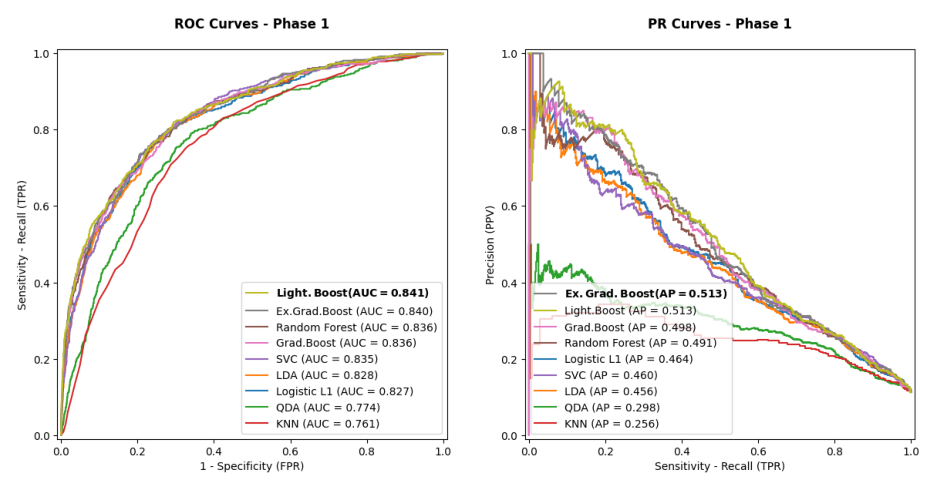

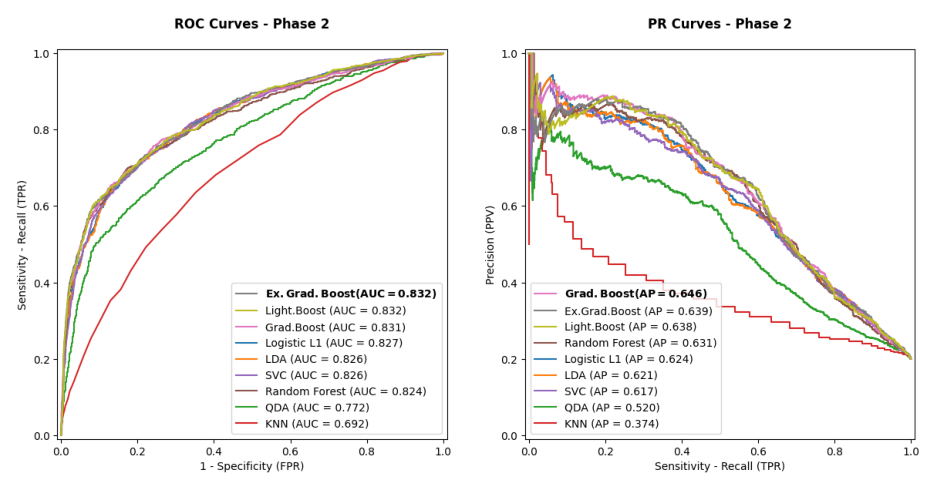

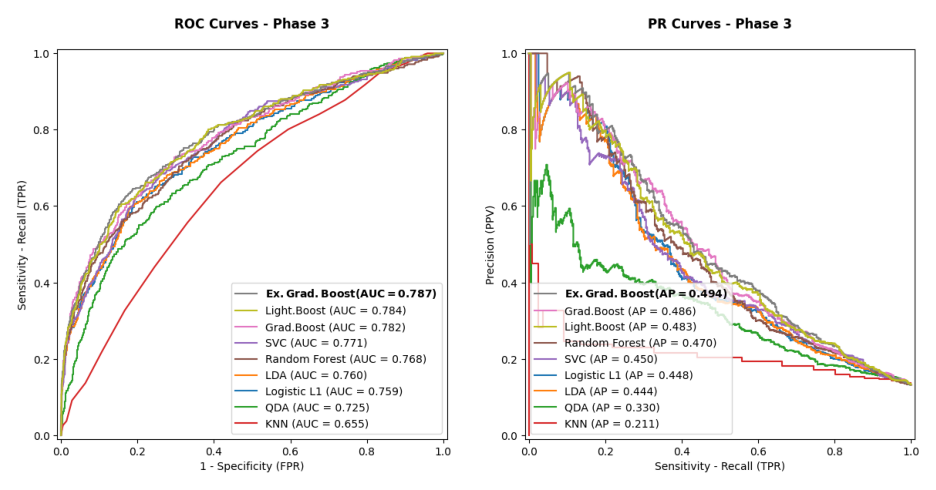

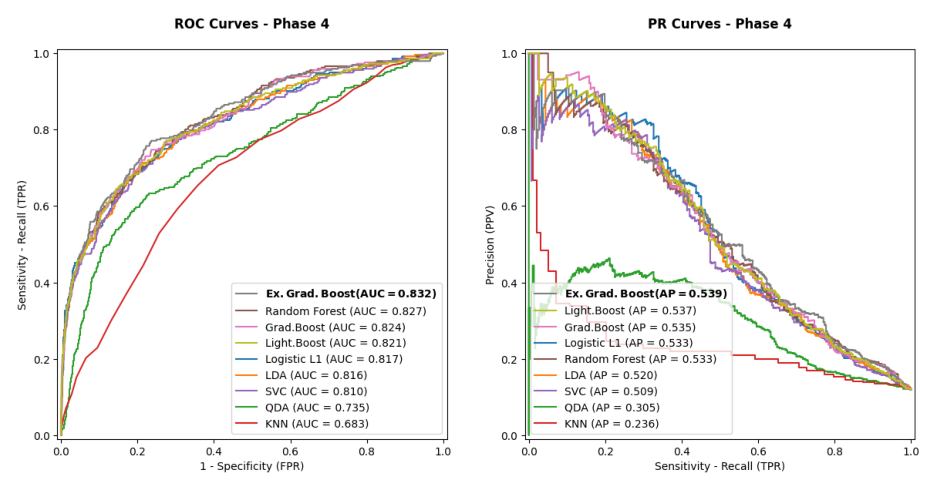

In [119]:
fun_fig_roc(roc1)
fun_fig_roc(roc2)
fun_fig_roc(roc3)
fun_fig_roc(roc4)


# Shap Plots

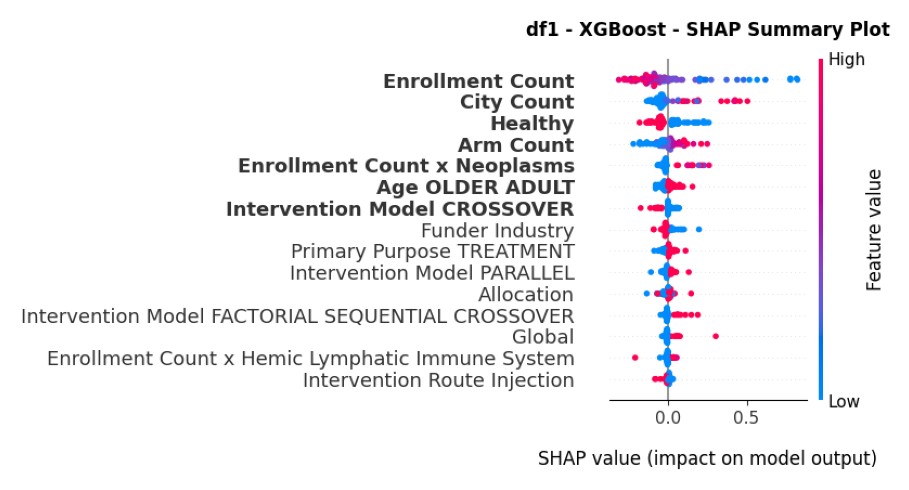

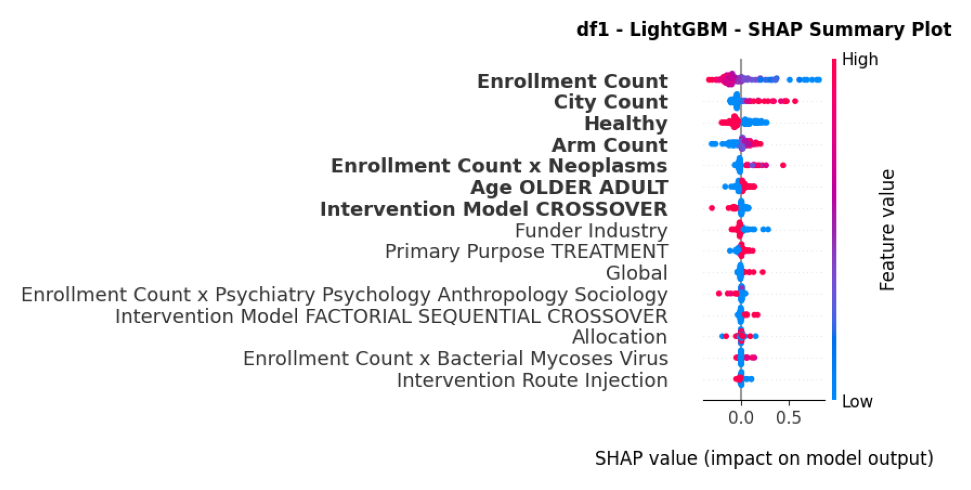

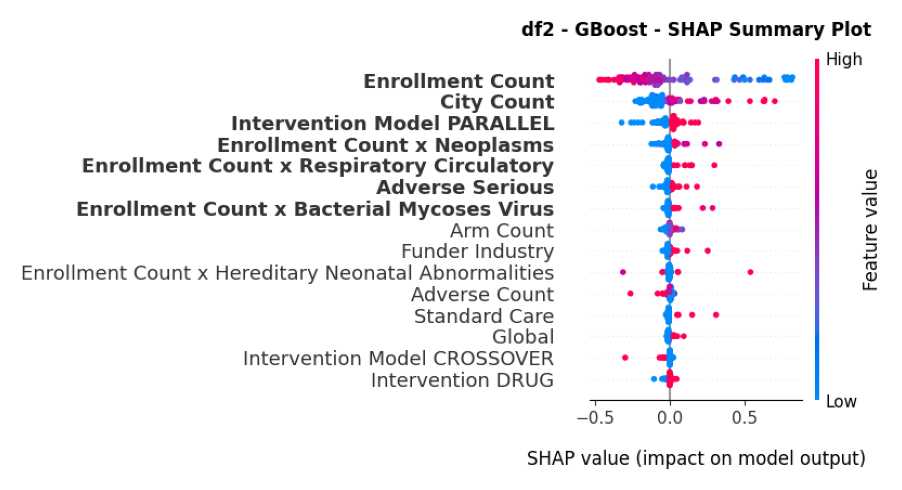

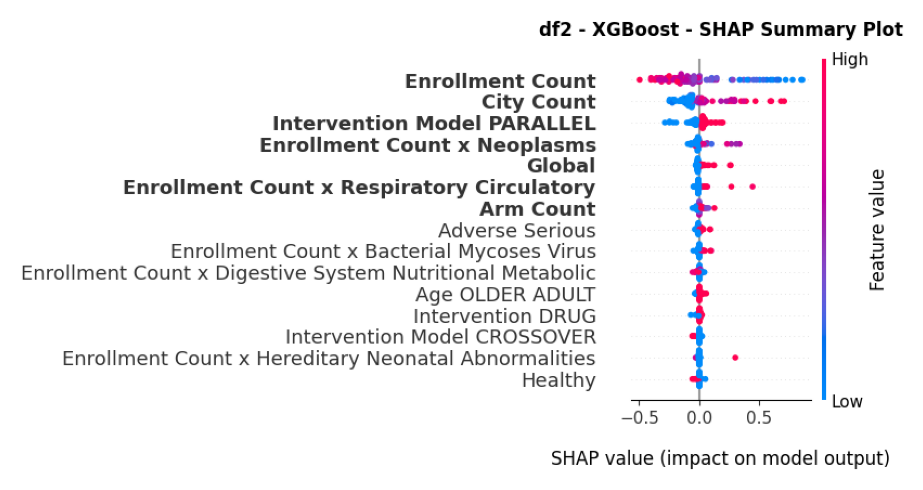

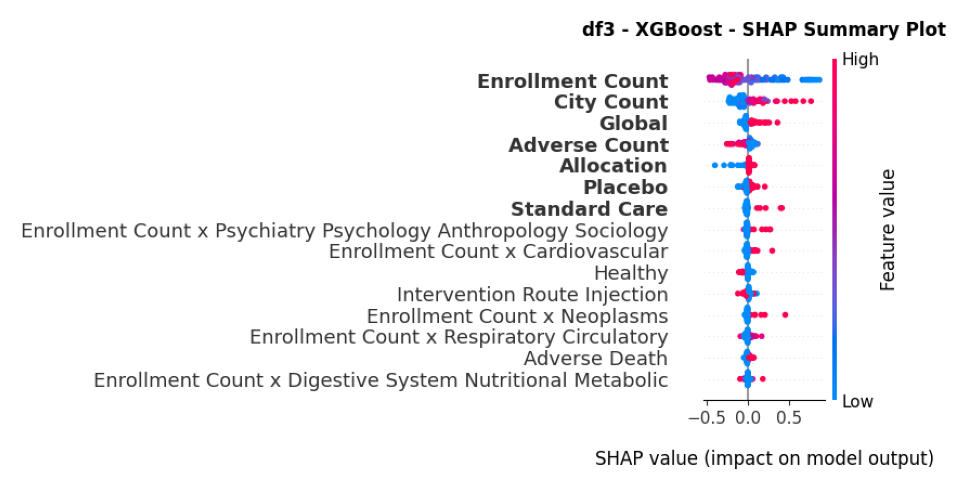

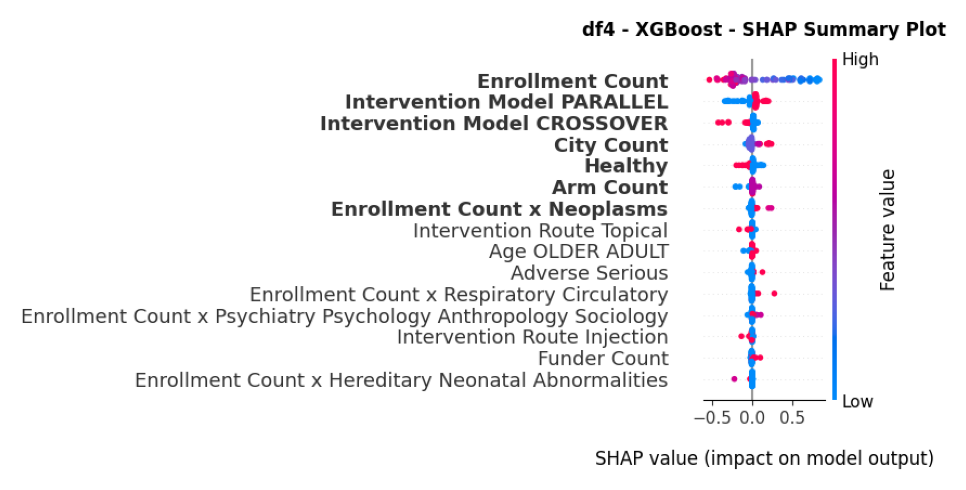

In [120]:
fun_fig_shap(xgb_shap1, lgb_shap1)
fun_fig_shap(gb_shap2, xgb_shap2)
fun_fig_shap(xgb_shap3, None)
fun_fig_shap(xgb_shap4, None)

# Metrics

In [121]:
metrics1.index.name = 'df1' 
metrics2.index.name = 'df2'
metrics3.index.name = 'df3' 
metrics4.index.name = 'df4'

display(metrics1, metrics2, metrics3, metrics4)

,Models,BACC,MCC,F1
df1,,,,
0,**Ex_Grad_Boost**,**76.21%**,**0.37**,**0.81**
2,LightGBM,75.93%,0.36,0.81
1,LDA,75.96%,0.35,0.79
3,Logistic,75.77%,0.35,0.79
4,SVC,75.62%,0.35,0.79
5,Random_Forest,75.07%,0.35,0.81
6,Grad_Boost,74.84%,0.35,0.80
7,QDA,72.34%,0.29,0.75
8,KNN,70.89%,0.27,0.72


,Models,BACC,MCC,F1
df2,,,,
0,**Random_Forest**,**76.15%**,**0.46**,**0.81**
1,LightGBM,75.70%,0.46,0.81
2,Grad_Boost,75.54%,0.45,0.80
3,Ex_Grad_Boost,75.38%,0.45,0.81
5,SVC,75.00%,0.43,0.79
4,LDA,75.00%,0.43,0.78
6,Logistic,74.97%,0.42,0.78
7,QDA,67.68%,0.28,0.66
8,KNN,60.71%,0.18,0.50


,Models,BACC,MCC,F1
df3,,,,
0,**Ex_Grad_Boost**,**72.13%**,**0.33**,**0.79**
1,LightGBM,71.80%,0.33,0.79
2,Grad_Boost,71.29%,0.32,0.78
4,Random_Forest,69.50%,0.30,0.80
3,SVC,70.30%,0.29,0.75
5,LDA,69.08%,0.27,0.74
6,Logistic,68.42%,0.26,0.73
7,QDA,64.77%,0.20,0.65
8,KNN,61.52%,0.16,0.59


,Models,BACC,MCC,F1
df4,,,,
2,**Grad_Boost**,**74.57%**,**0.40**,**0.85**
0,Ex_Grad_Boost,74.89%,0.39,0.84
5,Random_Forest,74.15%,0.39,0.84
3,LightGBM,74.57%,0.38,0.84
4,SVC,74.33%,0.37,0.82
1,LDA,74.69%,0.36,0.81
6,Logistic,74.01%,0.35,0.80
7,QDA,66.20%,0.21,0.68
8,KNN,57.47%,0.11,0.40


# Logistic 

In [122]:
X_train1 = pd.read_pickle(r".\df_models\X_train1.pkl")
X_train2 = pd.read_pickle(r".\df_models\X_train2.pkl")
X_train3 = pd.read_pickle(r".\df_models\X_train3.pkl")
X_train4 = pd.read_pickle(r".\df_models\X_train4.pkl")

X_test1 = pd.read_pickle(r".\df_models\X_test1.pkl")
X_test2 = pd.read_pickle(r".\df_models\X_test2.pkl")
X_test3 = pd.read_pickle(r".\df_models\X_test3.pkl")
X_test4 = pd.read_pickle(r".\df_models\X_test4.pkl")

y_train1 = pd.read_pickle(r".\df_models\y_train1.pkl")
y_train2 = pd.read_pickle(r".\df_models\y_train2.pkl")
y_train3 = pd.read_pickle(r".\df_models\y_train3.pkl")
y_train4 = pd.read_pickle(r".\df_models\y_train4.pkl")

y_test1 = pd.read_pickle(r".\df_models\y_test1.pkl")
y_test2 = pd.read_pickle(r".\df_models\y_test2.pkl")
y_test3 = pd.read_pickle(r".\df_models\y_test3.pkl")
y_test4 = pd.read_pickle(r".\df_models\y_test4.pkl")

In [123]:
def fun_log(X_test, y_test, shap_values):
    
    X = X_test[shap_values['Feature'].to_list()]
    display(shap_values)

    X = sm.add_constant(X)
    y = y_test

    model = sm.Logit(y, X)
    results = model.fit(method = 'lbfgs', maxiter = 1000)
    print(results.summary())
    print("\n")

fun_log(X_test1, y_test1, lgb_values1)
fun_log(X_test2, y_test2, xgb_values2)
fun_log(X_test3, y_test3, xgb_values3)
fun_log(X_test4, y_test4, xgb_values4)

,Feature,df1_LightGBM_Shap_Mean
0,Enrollment Count,0.176
1,City Count,0.094
2,Healthy,0.087
3,Arm Count,0.067
4,Enrollment Count x Neoplasms,0.038
5,Age OLDER ADULT,0.035
6,Intervention Model CROSSOVER,0.031
7,Funder Industry,0.029


                           Logit Regression Results                           
Dep. Variable:           Study Status   No. Observations:                 4203
Model:                          Logit   Df Residuals:                     4194
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Nov 2025   Pseudo R-squ.:                  0.2293
Time:                        00:46:25   Log-Likelihood:                -1139.6
converged:                       True   LL-Null:                       -1478.6
Covariance Type:            nonrobust   LLR p-value:                3.847e-141
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -0.2502      0.201     -1.245      0.213      -0.644       0.144
Enrollment Count                -8.9937      0.539    -16.695      0.000     

,Feature,df2_XGBoost_Shap_Mean
0,Enrollment Count,0.235
1,City Count,0.136
2,Intervention Model PARALLEL,0.054
3,Enrollment Count x Neoplasms,0.031
4,Global,0.023
5,Enrollment Count x Respiratory Circulatory,0.021
6,Arm Count,0.015
7,Adverse Serious,0.013


                           Logit Regression Results                           
Dep. Variable:           Study Status   No. Observations:                 3950
Model:                          Logit   Df Residuals:                     3941
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Nov 2025   Pseudo R-squ.:                  0.2602
Time:                        00:46:25   Log-Likelihood:                -1461.3
converged:                       True   LL-Null:                       -1975.2
Covariance Type:            nonrobust   LLR p-value:                1.541e-216
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
const                                          1.1440      0.127      8.986      0.000       0.894       1.394
Enrollment Count                   

,Feature,df3_XGBoost_Shap_Mean
0,Enrollment Count,0.266
1,City Count,0.136
2,Global,0.053
3,Adverse Count,0.049
4,Allocation,0.032
5,Placebo,0.031
6,Standard Care,0.027
7,Enrollment Count x Psychiatry Psychology Anthr...,0.022


                           Logit Regression Results                           
Dep. Variable:           Study Status   No. Observations:                 2664
Model:                          Logit   Df Residuals:                     2655
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Nov 2025   Pseudo R-squ.:                  0.1488
Time:                        00:46:25   Log-Likelihood:                -885.33
converged:                       True   LL-Null:                       -1040.1
Covariance Type:            nonrobust   LLR p-value:                 3.904e-62
                                                                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------
const                                                              -0.1024      0.212     -0.484      0.

,Feature,df4_XGBoost_Shap_Mean
0,Enrollment Count,0.304
1,Intervention Model PARALLEL,0.080
2,Intervention Model CROSSOVER,0.035
3,City Count,0.034
4,Healthy,0.032
5,Enrollment Count x Neoplasms,0.016
6,Arm Count,0.016
7,Intervention Route Topical,0.009


                           Logit Regression Results                           
Dep. Variable:           Study Status   No. Observations:                 2484
Model:                          Logit   Df Residuals:                     2475
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Nov 2025   Pseudo R-squ.:                  0.2459
Time:                        00:46:25   Log-Likelihood:                -685.70
converged:                       True   LL-Null:                       -909.29
Covariance Type:            nonrobust   LLR p-value:                 1.495e-91
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            0.6503      0.225      2.894      0.004       0.210       1.091
Enrollment Count               -15.1332      0.888    -17.034      0.000     

# Why Stopped
- Withdrawn, Terminated Trials reasons for stopping 

In [124]:
my_terminations = pd.read_pickle(r".\df_sql\my_terminations.pkl")
my_terminations2 = my_terminations[~my_terminations['phase'].isin(['PHASE1/PHASE2','PHASE2/PHASE3'])][['phase', 'why_stopped2']]

term_pivot = pd.pivot_table(
    data=my_terminations2,
    values='phase',          
    index='why_stopped2',
    columns='phase',
    aggfunc='size',          
    fill_value=0             
)

term_pivot.index.name = 'Why_Stopped_Full_Df'
term_pivot

phase,PHASE1,PHASE2,PHASE3,PHASE4
Why_Stopped_Full_Df,,,,
Administration,384,514,198,230
Covid,35,91,30,71
Efficacy,258,455,268,50
Enrollment,1331,2950,1127,1479
Funding,1037,1288,574,356
